# Image classification


This notebook is an example of image classification with both a dense neural network (multi-layer perceptron, or MLP) and a convolutional neural network (CNN). The example data are the MNIST hand-written digits.

![MNIST dataset sample from Wikipedia](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

The text, code and images after this cell were entirely written by AI...but look fairly good, so as a quick into to the topic, we're going with it!

This runs in Google Colab with a T4 GPU.

In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torchvision import datasets, transforms

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Image Classification: MLPs vs CNNs (PyTorch Version)

Welcome to this introductory notebook on image classification! We'll explore how neural networks can recognize handwritten digits from the MNIST dataset, comparing two approaches:

1. **Multilayer Perceptron (MLP)** - A simple fully connected network
2. **Convolutional Neural Network (CNN)** - A network designed specifically for image data

We'll see why CNNs typically perform better on image tasks while using fewer parameters.

## 1. Loading and Exploring the MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits (0-9), each 28x28 pixels.
- 60,000 training images
- 10,000 validation images
- Pixel values range from 0 to 255

In [ ]:
# Load MNIST dataset using PyTorch
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1] float tensor
])

# Download and load datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Print dataset info
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

In [ ]:
# Visualize some sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img, label = train_dataset[i]
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

## 2. Multilayer Perceptron (MLP) Approach

### How MLPs Work for Images

An MLP treats an image as a flat vector of pixels, losing all spatial information:

1. **Flattening**: Each 28x28 image becomes a vector of 784 (28×28) numbers
2. **Dense Layers**: Each neuron connects to every pixel in the previous layer
3. **Learning**: Neurons learn to detect patterns across the entire image

### Limitations of MLPs for Images

- **No Spatial Awareness**: Adjacent pixels in the image may be far apart in the vector
- **Parameter Explosion**: For 784 inputs → 128 hidden → 10 outputs:
  (784×128) + (128×10) = 100,480 + 1,280 = 101,760 parameters
- **Translation Sensitivity**: If a digit shifts slightly, the pattern changes completely

Let's build and train a simple MLP to see how it performs.

### Visualizing an MLP
Note that in the image below, the networks is simpler than our real MLP network. Rather than 5 inputs, ours has 784, etc.



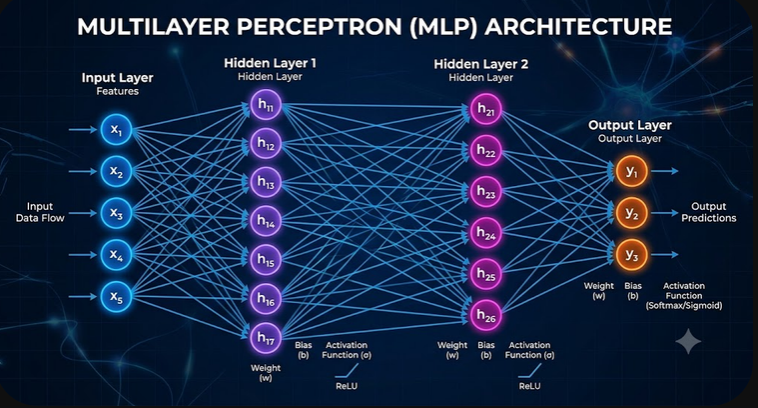


In [ ]:
# Define MLP model
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return F.log_softmax(x, dim=1)

# Create model instance
mlp_model = MLP().to(device)
print("MLP Architecture:")
print(mlp_model)

# Count parameters
mlp_params = sum(p.numel() for p in mlp_model.parameters())
print(f"\nMLP Total Parameters: {mlp_params:,}")

In [ ]:
# Training function
def train_model(model, train_loader, optimizer, epoch):
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    accuracy = 100. * correct / total
    avg_loss = train_loss / len(train_loader)
    return avg_loss, accuracy

In [ ]:
# Validation function
def val_model(model, val_loader):
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    val_loss /= len(val_loader.dataset)
    accuracy = 100. * correct / len(val_loader.dataset)
    return val_loss, accuracy

In [ ]:
# Train the MLP
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

mlp_train_losses = []
mlp_train_accuracies = []
mlp_val_losses = []
mlp_val_accuracies = []

epochs = 5
print("Training MLP...")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_model(mlp_model, train_loader, mlp_optimizer, epoch)
    val_loss, val_acc = val_model(mlp_model, val_loader)

    mlp_train_losses.append(train_loss)
    mlp_train_accuracies.append(train_acc)
    mlp_val_losses.append(val_loss)
    mlp_val_accuracies.append(val_acc)

    print(f'Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

In [ ]:
# Plot training progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), mlp_train_accuracies, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), mlp_val_accuracies, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('MLP: Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), mlp_train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), mlp_val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP: Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('MLP Training Progress')
plt.tight_layout()
plt.show()

## 3. Convolutional Neural Network (CNN) Approach

### How Convolution Works

Instead of connecting every input to every neuron, CNNs use **convolutional layers** that:

1. **Apply Filters (Kernels)**: Small matrices that slide across the image
2. **Detect Features**: Each kernel learns to detect specific patterns (edges, curves, etc.)
3. **Preserve Spatial Structure**: Nearby pixels remain nearby in the representation
4. **Share Parameters**: The same kernel is used everywhere, drastically reducing parameters

### Why CNNs Are Better for Images

- **Spatial Hierarchy**: Builds understanding from simple to complex features
- **Parameter Sharing**: Same filter detects features everywhere in the image
- **Translation Invariance**: Features recognized regardless of position
- **Local Processing**: Early layers focus on small regions, building up to global understanding

Let's build a CNN and see how it compares.


### Visualizing the Convolution Operation

The image below gives a general idea of the convolution operation.

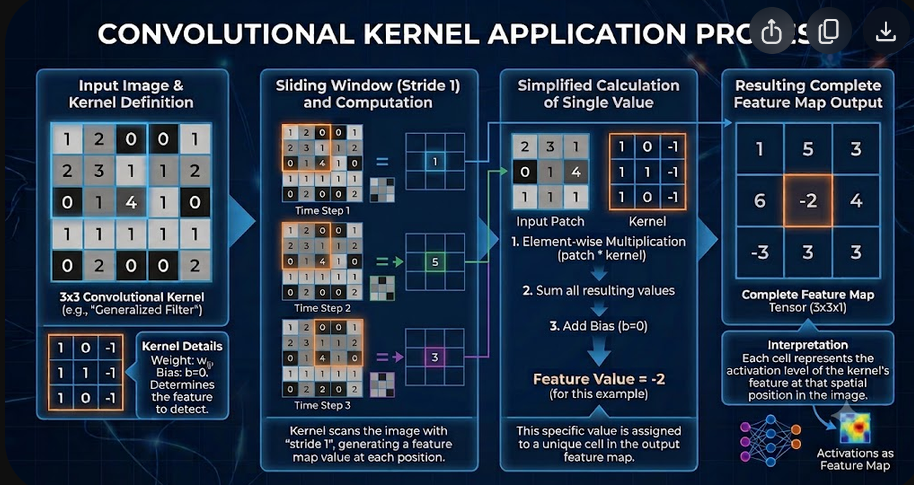

In [ ]:
# Define CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First conv block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 28x28 -> 28x28
        self.pool1 = nn.MaxPool2d(2, 2)  # 28x28 -> 14x14
        # Second conv block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14 -> 14x14
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 -> 7x7
        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Create model instance
cnn_model = CNN().to(device)
print("CNN Architecture:")
print(cnn_model)

# Count parameters
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"\nCNN Total Parameters: {cnn_params:,}")
print(f"Parameter Reduction vs MLP: {((mlp_params - cnn_params) / mlp_params * 100):.1f}%")

In [ ]:
# Train the CNN
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_train_losses = []
cnn_train_accuracies = []
cnn_val_losses = []
cnn_val_accuracies = []

print("\nTraining CNN...")
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_model(cnn_model, train_loader, cnn_optimizer, epoch)
    val_loss, val_acc = val_model(cnn_model, val_loader)

    cnn_train_losses.append(train_loss)
    cnn_train_accuracies.append(train_acc)
    cnn_val_losses.append(val_loss)
    cnn_val_accuracies.append(val_acc)

    print(f'Epoch {epoch:2d}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

In [ ]:
# Plot training progress
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), cnn_train_accuracies, label='Train Accuracy', marker='o')
plt.plot(range(1, epochs+1), cnn_val_accuracies, label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('CNN: Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), cnn_train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), cnn_val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN: Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('CNN Training Progress')
plt.tight_layout()
plt.show()

## 4. Comparing MLP vs CNN

Let's summarize the key differences and results.

In [ ]:
# Final comparison
final_mlp_acc = mlp_val_accuracies[-1]
final_cnn_acc = cnn_val_accuracies[-1]

print(f"MLP Final Validation Accuracy: {final_mlp_acc:.2f}%")
print(f"CNN Final Validation Accuracy: {final_cnn_acc:.2f}%")
print(f"Accuracy Improvement: {final_cnn_acc - final_mlp_acc:.2f}%pts")
print(f"\nMLP Parameters: {mlp_params:,}")
print(f"CNN Parameters: {cnn_params:,}")
print(f"Parameter Reduction: {((mlp_params - cnn_params) / mlp_params * 100):.1f}%")

# Create comparison charts
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Parameters comparison
ax1.bar(['MLP', 'CNN'], [mlp_params, cnn_params], color=['skyblue', 'lightcoral'])
ax1.set_ylabel('Number of Parameters')
ax1.set_title('Model Complexity')
ax1.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
ax1.set_ylim(1e5, 2.5e5)
for i, v in enumerate([mlp_params, cnn_params]):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom')

# Accuracy comparison
ax2.bar(['MLP', 'CNN'], [final_mlp_acc, final_cnn_acc], color=['skyblue', 'lightcoral'])
ax2.set_ylabel('Validation Accuracy (%)')
ax2.set_title('Final Validation Accuracy')
ax2.set_ylim(90, 100)
for i, v in enumerate([final_mlp_acc, final_cnn_acc]):
    ax2.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

# Training accuracy comparison
ax3.plot(range(1, epochs+1), mlp_train_accuracies, label='MLP Train', marker='o', linewidth=2, color='green')
ax3.plot(range(1, epochs+1), cnn_train_accuracies, label='CNN Train', marker='s', linewidth=2, color='blue')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy (%)')
ax3.set_title('Training Accuracy Comparison')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Validation accuracy comparison
ax4.plot(range(1, epochs+1), mlp_val_accuracies, label='MLP Validation', marker='o', linewidth=2, color='green')
ax4.plot(range(1, epochs+1), cnn_val_accuracies, label='CNN Validation', marker='s', linewidth=2, color='blue')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy (%)')
ax4.set_title('Validation Accuracy Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('MLP vs CNN Performance Comparison')
plt.tight_layout()
plt.show()

## 5. Key Takeaways

### Why CNNs Work Better for Images

1. **Spatial Hierarchy**: CNNs preserve and build upon spatial relationships
   - Early layers: edges, lines, curves
   - Middle layers: textures, shapes
   - Late layers: object parts, full objects

2. **Parameter Sharing**: The same kernel detects features everywhere
   - Dramatically reduces number of parameters
   - Makes the model more efficient and less prone to overfitting

3. **Translation Invariance**: Features detected in one location are recognized elsewhere
   - A digit in the corner is recognized the same as in the center

4. **Local Receptive Fields**: Neurons only look at small regions at first
   - Builds up to global understanding through layers

### When to Use Which

- **Use MLPs for**:
  - Tabular data (spreadsheets, databases)
  - When spatial relationships don't matter
  - Very simple problems as a starting point

- **Use CNNs for**:
  - Image data (photographs, medical scans, satellite imagery)
  - Video data (treating frames as images)
  - Any data with grid-like structure (spectrograms, etc.)

### Next Steps for Exploration

1. Try deeper networks (more layers)
2. Experiment with different kernel sizes and numbers of filters
3. Add dropout or batch normalization for regularization
4. Try learning rate schedulers
5. Explore data augmentation (rotating, shifting images)
6. Try pre-trained networks like ResNet for transfer learning

Remember: The best way to learn is by experimenting! Try changing the architectures and see what happens.